In [5]:
import os
import torch
import numpy as np
import pyexr
import matplotlib.pyplot as plt

In [6]:
test_index = "5500" 
pred_file_path = r"C:\Users\Kai Kumano\workspace\CGH-depth\results\engineered_predictions\engineered_pred_5500.exr"
recon_save_dir = r"C:\Users\Kai Kumano\workspace\CGH-depth\results\reconstructions\engineered_5500"
os.makedirs(recon_save_dir, exist_ok=True)

# Hardware and Physics Parameters
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PITCH = 3.6e-6      # 3.6 micrometers
WAVELENGTH = 638e-9 # 638 nanometers (Red)

In [7]:
def reconstruct_asm(amp, phs, z, pitch=3.6e-6, wavelength=638e-9):
    """
    Propagates the complex field to distance z using Angular Spectrum Method.
    """
    res_y, res_x = amp.shape
    
    # Form Complex Wavefront: U = A * exp(j * phi)
    u_hologram = torch.complex(amp * torch.cos(phs), amp * torch.sin(phs))
    
    # Fourier Transform and Shift
    u_freq = torch.fft.fftshift(torch.fft.fft2(u_hologram))
    
    # Frequency Coordinates
    fy = torch.fft.fftfreq(res_y, d=pitch, device=amp.device)
    fx = torch.fft.fftfreq(res_x, d=pitch, device=amp.device)
    fyy, fxx = torch.meshgrid(fy, fx, indexing='ij')
    fyy, fxx = torch.fft.fftshift(fyy), torch.fft.fftshift(fxx)
    
    # Transfer Function (Kernel)
    k = 2 * np.pi / wavelength
    term = 1 - (wavelength * fxx)**2 - (wavelength * fyy)**2
    kernel = torch.exp(1j * k * z * torch.sqrt(torch.clamp(term, min=0)))
    
    # Inverse Transform back to Spatial Domain
    u_reconstructed = torch.fft.ifft2(torch.fft.ifftshift(u_freq * kernel))
    
    # Return Intensity
    return torch.abs(u_reconstructed)**2

Saved: C:\Users\Kai Kumano\workspace\CGH-depth\results\reconstructions\engineered_5500\recon_idx5500_5mm.png
Saved: C:\Users\Kai Kumano\workspace\CGH-depth\results\reconstructions\engineered_5500\recon_idx5500_10mm.png
Saved: C:\Users\Kai Kumano\workspace\CGH-depth\results\reconstructions\engineered_5500\recon_idx5500_15mm.png
Saved: C:\Users\Kai Kumano\workspace\CGH-depth\results\reconstructions\engineered_5500\recon_idx5500_20mm.png
Saved: C:\Users\Kai Kumano\workspace\CGH-depth\results\reconstructions\engineered_5500\recon_idx5500_25mm.png


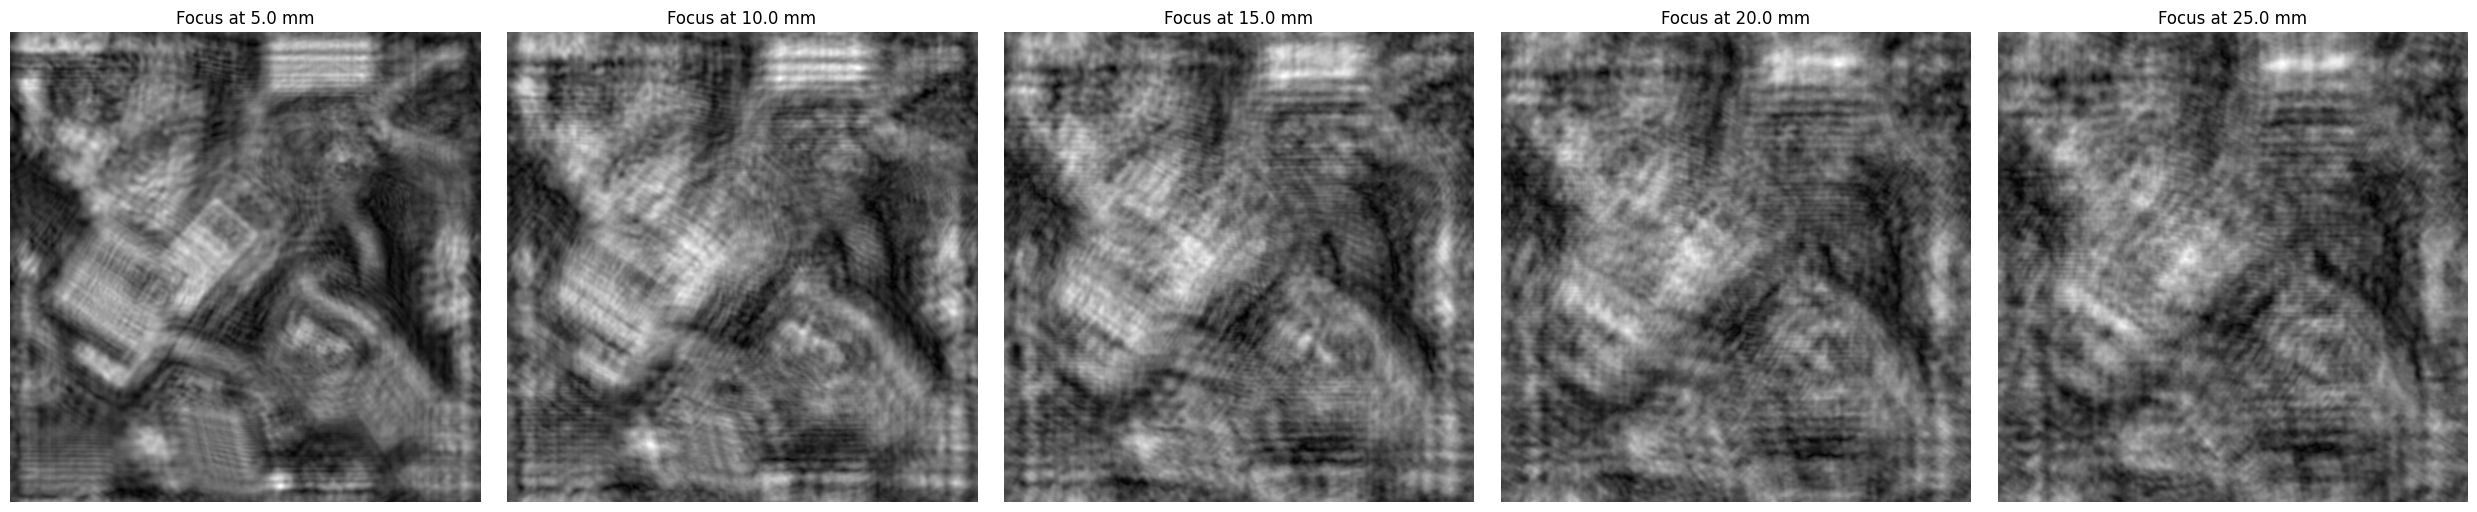

In [8]:
if not os.path.exists(pred_file_path):
    print(f"ERROR: File not found at {pred_file_path}")
else:
    # Load the EXR (Channel 0=Amp, Channel 1=Phase)
    data = pyexr.open(pred_file_path).get().astype(np.float32)
    pred_amp = torch.from_numpy(data[:, :, 0]).to(device)
    pred_phs = torch.from_numpy(data[:, :, 1]).to(device)

    # --- 4. FOCUS SWEEP & SAVING ---
    # Define depths to test (e.g., 5mm to 25mm)
    depths_to_test = [0.005, 0.010, 0.015, 0.020, 0.025] 

    plt.figure(figsize=(25, 5))

    for i, z in enumerate(depths_to_test):
        # 1. Perform reconstruction
        recon_intensity = reconstruct_asm(pred_amp, pred_phs, z, pitch=PITCH, wavelength=WAVELENGTH)
        
        # 2. Process for saving (Applying square root/gamma for better PNG visibility)
        recon_np = recon_intensity.cpu().numpy()
        recon_normalized = np.sqrt(recon_np) 
        
        # 3. Define filename and save
        file_name = f"recon_idx{test_index}_{int(z*1000)}mm.png"
        save_path = os.path.join(recon_save_dir, file_name)
        
        plt.imsave(save_path, recon_normalized, cmap='gray')
        print(f"Saved: {save_path}")

        # 4. Display in Jupyter
        plt.subplot(1, len(depths_to_test), i+1)
        plt.imshow(recon_normalized, cmap='gray')
        plt.title(f"Focus at {z*1000:.1f} mm")
        plt.axis('off')

    plt.tight_layout()
    plt.show()